In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
import joblib

Cargamos los datos para nuestro modelo

In [4]:
df = pd.read_csv("../csv/clean_cars.csv")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 192378 entries, 0 to 192377
Data columns (total 75 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   brand                192378 non-null  object 
 1   model                192378 non-null  object 
 2   model_year           192378 non-null  int64  
 3   milage               192378 non-null  int64  
 4   fuel_type            192378 non-null  object 
 5   transmission         192378 non-null  object 
 6   ext_col              192378 non-null  object 
 7   int_col              192378 non-null  object 
 8   accident             192378 non-null  int64  
 9   clean_title          192378 non-null  int64  
 10  price                192378 non-null  int64  
 11  brand_Alfa           192378 non-null  bool   
 12  brand_Aston          192378 non-null  bool   
 13  brand_Audi           192378 non-null  bool   
 14  brand_BMW            192378 non-null  bool   
 15  brand_Bentley    

#### Preparamos x e y

In [5]:
# Target
y = df['price']

# Features (SOLO numéricas)
x = df.drop(columns=[
    'price',
    'brand',
    'transmission',
    'int_col',
    'ext_col',
    'model',
    'fuel_type',
])

y_log = np.log1p(y)

x_train, x_test, y_train, y_test = train_test_split(
    x, y_log, test_size=0.2, random_state=42
)

y_test_real = np.expm1(y_test)


#### Métricas de evaluación

In [6]:
def evaluate_model(y_true, y_pred):
    return{
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred)
    }

#### Random Forest Regressor

In [7]:
# Random Forest
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=1
)

rf.fit(x_train, y_train)

# Predicciones (log → real)
y_pred_rf_train = np.expm1(rf.predict(x_train))
y_pred_rf_test  = np.expm1(rf.predict(x_test))

#### Gradient Boosting

In [8]:
# Gradient Boosting
gbr = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gbr.fit(x_train, y_train)

# Predicciones (log → real)
y_pred_gbr_train = np.expm1(gbr.predict(x_train))
y_pred_gbr_test  = np.expm1(gbr.predict(x_test))

####  HGB

In [9]:
hgb = HistGradientBoostingRegressor(
    max_depth=8,
    learning_rate=0.05,
    max_iter=400,
    l2_regularization=0.1,
    random_state=42
)

hgb.fit(x_train, y_train)

# Predicciones (log → real)
y_pred_hgb_train = np.expm1(hgb.predict(x_train))
y_pred_hgb_test  = np.expm1(hgb.predict(x_test))

#### Elección del modelo


##### RMSE
##### Random Forest / GBR

In [10]:
importances = pd.Series(
    gbr.feature_importances_,
    index = x.columns
).sort_values(ascending=False)

importances.head(15)

milage                 0.466559
model_year             0.417921
horsepower             0.064646
engine_liters          0.023972
brand_Porsche          0.007898
accident               0.003487
cylinders              0.002811
turbo                  0.002634
brand_Lamborghini      0.002571
brand_Chevrolet        0.001348
brand_Mercedes-Benz    0.001290
brand_Bentley          0.001256
fuel_diesel            0.000829
brand_Rolls-Royce      0.000626
brand_Hyundai          0.000348
dtype: float64

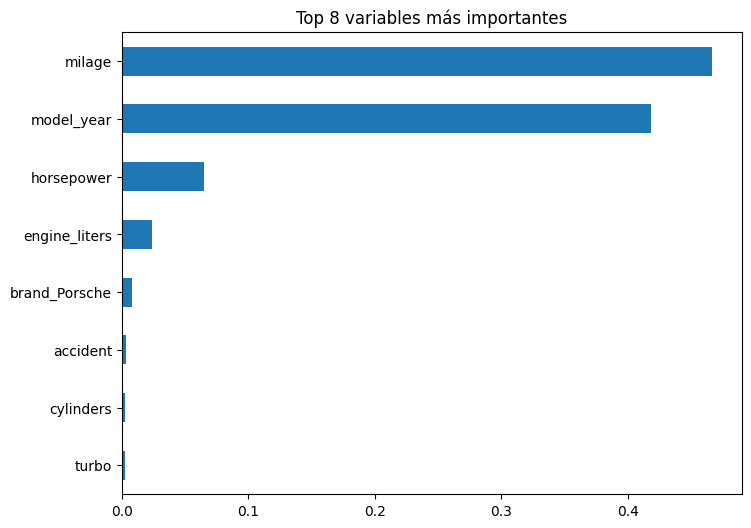

In [11]:
importances.head(8).plot(kind='barh', figsize=(8,6))
plt.title('Top 8 variables más importantes')
plt.gca().invert_yaxis()
plt.show()

#### Análisis de errores

##### Predicción vs real

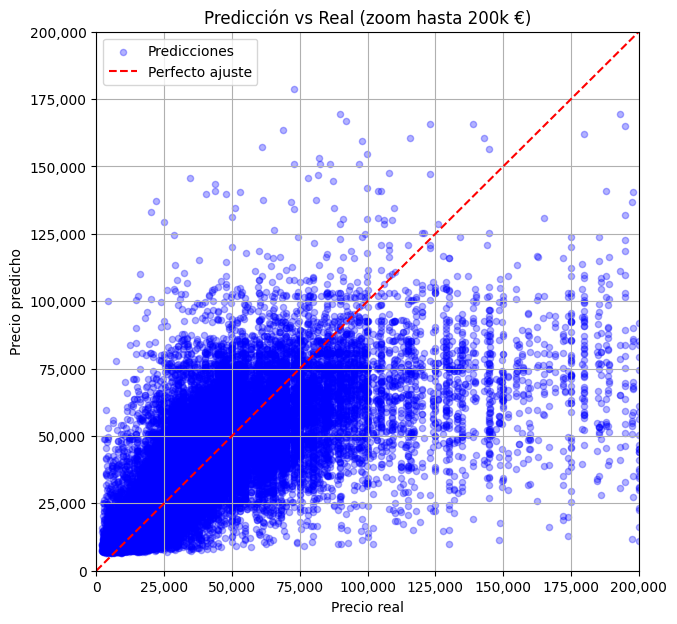

In [12]:
plt.figure(figsize=(7,7))
plt.scatter(y_test_real, np.expm1(gbr.predict(x_test)),
            alpha=0.3, s=20, color='blue', label='Predicciones')

plt.plot([0, 200_000], [0, 200_000], linestyle='--', color='red', label='Perfecto ajuste')

plt.xlim(0, 200_000)
plt.ylim(0, 200_000)

plt.xlabel('Precio real')
plt.ylabel('Precio predicho')
plt.title('Predicción vs Real (zoom hasta 200k €)')

plt.gca().xaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

plt.grid(True)
plt.legend()
plt.show()


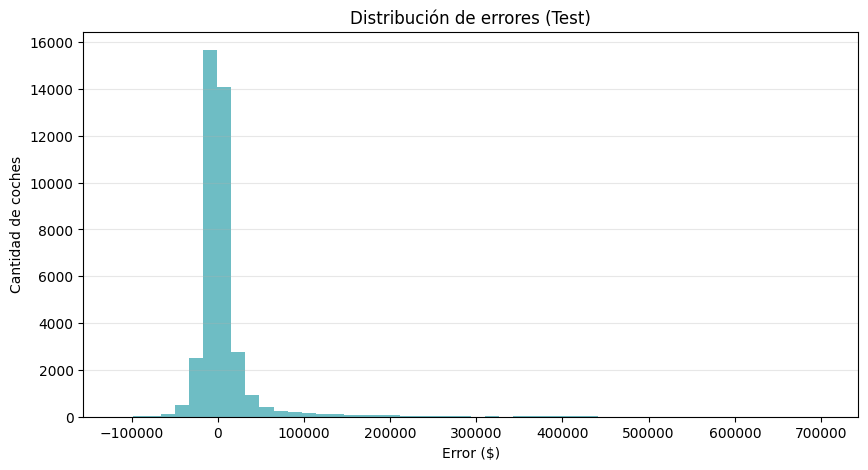

In [13]:
# Predicciones de test
y_pred_gbr_test = np.expm1(gbr.predict(x_test))

# Errores
errors = y_test_real - y_pred_gbr_test

# Histograma
plt.figure(figsize=(10,5))
plt.hist(errors, bins=50, color='#31A2AC', alpha=0.7)
plt.title('Distribución de errores (Test)')
plt.xlabel('Error ($)')
plt.ylabel('Cantidad de coches')
plt.grid(axis='y', alpha=0.3)
plt.show()


#### Validación cruzada

In [14]:
cv_rmse = np.sqrt(
    -cross_val_score(
        gbr, x, y_log,
        cv=5,
        scoring='neg_mean_squared_error'
    )
)

cv_rmse.mean(), cv_rmse.std()

(np.float64(0.4876278303143195), np.float64(0.0035517397630057206))

In [16]:
cv_rmse = np.sqrt(
    -cross_val_score(
        rf, x, y_log,
        cv=5,
        scoring='neg_mean_squared_error'
    )
)

cv_rmse.mean(), cv_rmse.std()

(np.float64(0.48447304593166207), np.float64(0.004382361721861538))

In [17]:
cv_rmse = np.sqrt(
    -cross_val_score(
        hgb, x, y_log,
        cv=5,
        scoring='neg_mean_squared_error'
    )
)

cv_rmse.mean(), cv_rmse.std()

(np.float64(0.47930099806903115), np.float64(0.004385646073388567))

#### Ajuste de hiperparametros

In [18]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.03, 0.05]
}

grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

grid.fit(x_train, y_train)
grid.best_params_

{'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200}

In [19]:
# Revertir y reales
y_train_real = np.expm1(y_train)
y_test_real  = np.expm1(y_test)

y_pred_gbr_train = np.expm1(gbr.predict(x_train))
y_pred_gbr_test  = np.expm1(gbr.predict(x_test))

y_pred_rf_train  = np.expm1(rf.predict(x_train))
y_pred_rf_test   = np.expm1(rf.predict(x_test))

y_pred_hgb_train = np.expm1(hgb.predict(x_train))
y_pred_hgb_test  = np.expm1(hgb.predict(x_test))

In [20]:
# MAE
mae_train_gbr = mean_absolute_error(y_train_real, y_pred_gbr_train)
mae_test_gbr  = mean_absolute_error(y_test_real, y_pred_gbr_test)

mae_train_rf = mean_absolute_error(y_train_real, y_pred_rf_train)
mae_test_rf  = mean_absolute_error(y_test_real, y_pred_rf_test)

mae_train_hgb = mean_absolute_error(y_train_real, y_pred_hgb_train)
mae_test_hgb  = mean_absolute_error(y_test_real, y_pred_hgb_test)

In [21]:
overfit_gbr = (mae_test_gbr - mae_train_gbr) / mae_train_gbr * 100
overfit_rf  = (mae_test_rf  - mae_train_rf)  / mae_train_rf  * 100
overfit_hgb = (mae_test_hgb - mae_train_hgb) / mae_train_hgb * 100

print("Overfitting (%) por modelo:")
print(f"GBR: {overfit_gbr:.2f}%")
print(f"RF:  {overfit_rf:.2f}%")
print(f"HGB: {overfit_hgb:.2f}%")

Overfitting (%) por modelo:
GBR: 1.06%
RF:  16.27%
HGB: 2.47%


#### Comparar modelos

In [22]:
# --- Asegurarnos de tener y_train_real ---
y_train_real = np.expm1(y_train)

# --- Evaluar modelos en TRAIN ---
results_train = {
    'RF': evaluate_model(y_train_real, y_pred_rf_train),
    'GBR': evaluate_model(y_train_real, y_pred_gbr_train),
    'HGB': evaluate_model(y_train_real, y_pred_hgb_train),
}

# --- Convertir a DataFrame para ver resultados ---
pd.DataFrame(results_train).T

,MAE,RMSE,R2
RF,13591.424742,35898.298149,0.462388
GBR,15800.486763,40879.529504,0.302839
HGB,15290.339902,39851.458085,0.337463


#### Preparar modelos

In [23]:
# Guardar modelos entrenados
#joblib.dump(gbr, "../models/gbr_model.pkl")
#joblib.dump(rf, "../models/rf_model.pkl")
#joblib.dump(hgb, "../models/hgb_model.pkl")

# Guardar valores reales de test
#joblib.dump(y_test_real, "../models/y_test_real.pkl")

# Guardar predicciones del test (en €)
#joblib.dump(y_pred_gbr_test, "../models/y_pred_gbr.pkl")
#joblib.dump(y_pred_rf_test,  "../models/y_pred_rf.pkl")
#joblib.dump(y_pred_hgb_test, "../models/y_pred_hgb.pkl")